In [1]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects
import os
import numpy as np
import platosim.referenceFrames as rf
import matplotlib.pyplot as plt
from scipy import constants
from math import radians, degrees

In [2]:
sim = Simulation("StarPosition")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

In [3]:
ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

# Focal-plane coordinates at the centre of the CCD [mm]

# xFP = sim["SubField/NumColumns"] / 2 * pixelSize
# yFP = sim["SubField/NumRows"] / 2 * pixelSize

# focalLength = sim["Camera/FocalLength/ConstantValue"] / constants.milli
# raPlatform = radians(sim["ObservingParameters/RApointing"])
# decPlatform = radians(sim["ObservingParameters/DecPointing"])

# # Sky coordinates at the centre of the CCD [radians]

# ra, dec = rf.focalPlaneToSkyCoordinates(-xFP, yFP, raPlatform, decPlatform, 0, 0, 0, 0, focalLength)

print(rf.skyToPixelCoordinates(sim, ra, dec, True))

ra = degrees(ra)
dec = degrees(dec)


('2', 4.500000000001096, 4.500000000004132)


In [4]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

output = sim.run(removeOutputFile = True)

In [5]:
image = output.getImage(0)

In [6]:
print(image)

[[  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835. 108678.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]
 [  5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.   5835.]]


In [7]:
image[4][4]

108678.0

In [8]:
np.unique(image)

array([  5835., 108678.], dtype=float32)

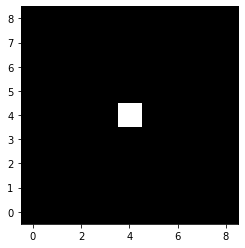

In [9]:
plt.imshow(-image, origin='lower', cmap='Greys')